In [1]:
from kaggle_environments import make

env = make('connectx')

rows = env.configuration.rows
columns = env.configuration.columns
inarow = env.configuration.inarow

assert rows == 6
assert columns == 7
assert inarow == 4

In [2]:
import torch
import numpy as np
import os

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

In [3]:
from types import SimpleNamespace
from my_dqn import My_DQN

device = 'cuda'
env_config = env.configuration
my_config = SimpleNamespace(
    h=128
)

Q_func = My_DQN(env_config, my_config, device)

In [4]:
Y = Q_func(torch.ones(5, 42, device=device))
print(Y)

tensor([[-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


---


Initialize replay memory $D$ to capacity $N$

Initialize action-value function $Q$ with random weights $\theta$

Initialize target action-value function $\hat{Q}$ with weights $\theta^- = \theta$

**For** episode $= 1, M$ **do**

$\quad$ Initialize sequence $s_1 = \{x_1\}$ and preprocessed sequence $\phi_1 = \phi(s_1)$

$\quad$ **For** $t = 1, T$ **do**

$\qquad$ With probability $\varepsilon$ select a random action $a_t$

$\qquad$ otherwise select $a_t = \text{argmax}_a Q(\phi(s_t), a; \theta)$

$\qquad$ Execute action $a_t$ in emulator and observe reward $r_t$ and image $x_{t+1}$

$\qquad$ Set $s_{t+1} = s_t, a_t, x_{t+1}$ and preprocess $\phi_{t+1} = \phi(s_{t+1})$

$\qquad$ Store transition $(\phi_t, a_t, r_t, \phi_{t+1})$ in $D$

$\qquad$ Sample random minibatch of transitions $(\phi_j, a_j, r_j, \phi_{j+1})$ from $D$

$\qquad$ Set $y_j = \begin{cases} r_j & \text{if episode terminates at step } j+1 \\ r_j + \gamma \max_{a'} \hat{Q}(\phi_{j+1}, a'; \theta^-) & \text{otherwise} \end{cases}$

$\qquad$ Perform a gradient descent step on $\left(y_j - Q(\phi_j, a_j; \theta)\right)^2$ with respect to the network parameters $\theta$

$\qquad$ Every $C$ steps reset $\hat{Q} = Q$

$\quad$ **End For**

**End For**

In [5]:
reward_for_inarow = torch.arange(inarow + 1, device=device) / inarow
reward_for_inarow[:2] = 0

train_config = SimpleNamespace(
    batch_size = 32,
    total_steps = 10000,
    epsilon = 0.1, # ???

    validate_every = 1000,
    num_episodes = 100,

    reward_for_None = -5,
    reward_for_inarow = reward_for_inarow,
    state_reward_coeff = 0.01
)

In [6]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

optimizer = AdamW(Q_func.parameters())
scheduler = LinearLR(
    optimizer, 
    start_factor=0.1, 
    end_factor=1, 
    total_iters=(train_config.total_steps - 2 * train_config.batch_size) / 2)

In [7]:
from train import train

logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, op_agent='random', device=device)

step: 0
step: 100
step: 200
step: 300
step: 400
step: 500
step: 600
step: 700
step: 800
step: 900
step: 1000
step: 1100
step: 1200
step: 1300
step: 1400
step: 1500
step: 1600
step: 1700
step: 1800
step: 1900
step: 2000
step: 2100
step: 2200
step: 2300
step: 2400
step: 2500
step: 2600
step: 2700
step: 2800
step: 2900
step: 3000
step: 3100
step: 3200
step: 3300
step: 3400
step: 3500
step: 3600
step: 3700
step: 3800
step: 3900
step: 4000
step: 4100
step: 4200
step: 4300
step: 4400
step: 4500
step: 4600
step: 4700
step: 4800
step: 4900
step: 5000
step: 5100
step: 5200
step: 5300
step: 5400
step: 5500
step: 5600
step: 5700
step: 5800
step: 5900
step: 6000
step: 6100
step: 6200
step: 6300
step: 6400
step: 6500
step: 6600
step: 6700
step: 6800
step: 6900
step: 7000
step: 7100
step: 7200
step: 7300
step: 7400
step: 7500
step: 7600
step: 7700
step: 7800
step: 7900
step: 8000
step: 8100
step: 8200
step: 8300
step: 8400
step: 8500
step: 8600
step: 8700
step: 8800
step: 8900
step: 9000
step: 9100


In [8]:
# train_config.total_steps = 10000
# logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, op_agent='negamax', device=device)

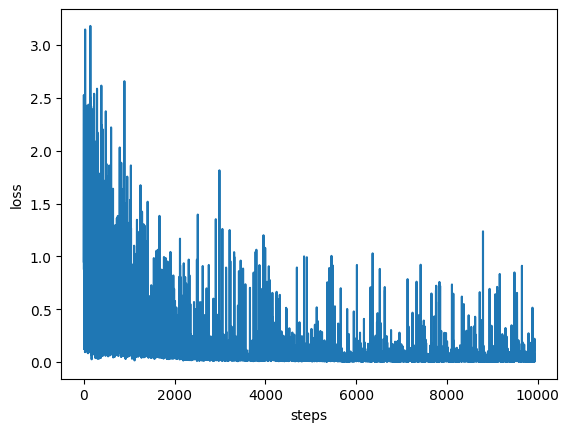

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=range(len(logs['loss'])), y=logs['loss'])
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

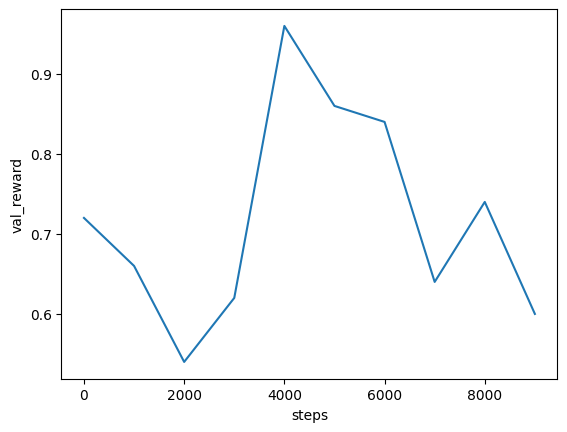

In [10]:
sns.lineplot(
    x=range(0, train_config.total_steps, train_config.validate_every), 
    y=logs['val_reward']
)
plt.xlabel('steps')
plt.ylabel('val_reward')
plt.show()

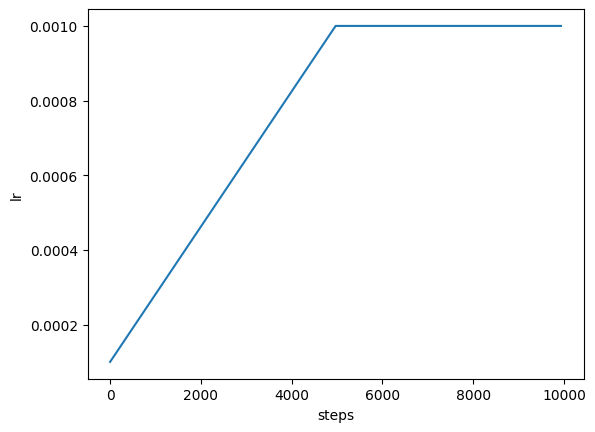

In [11]:
sns.lineplot(x=range(len(logs['lr'])), y=logs['lr'])
plt.xlabel('steps')
plt.ylabel('lr')
plt.show()